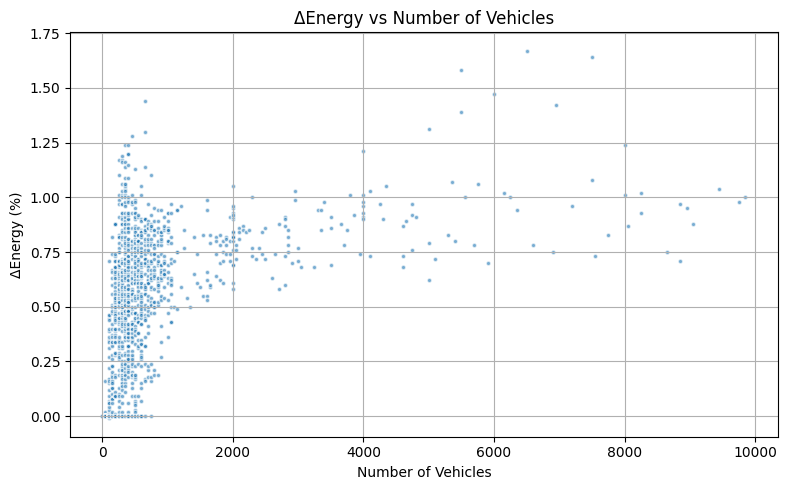

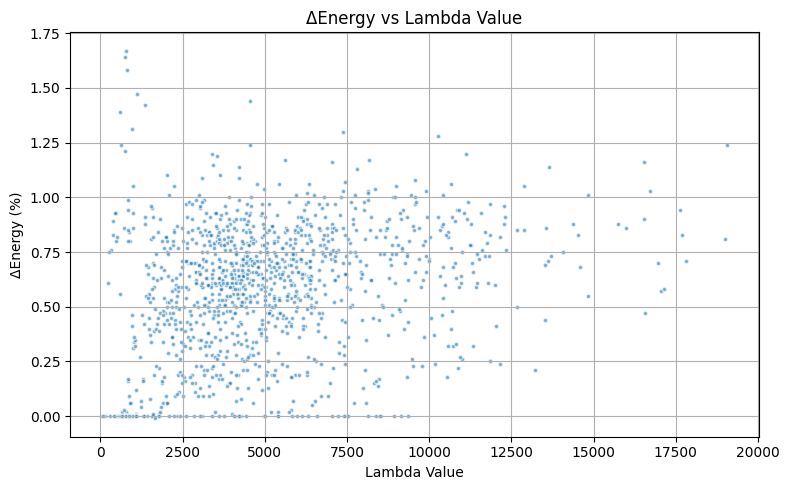

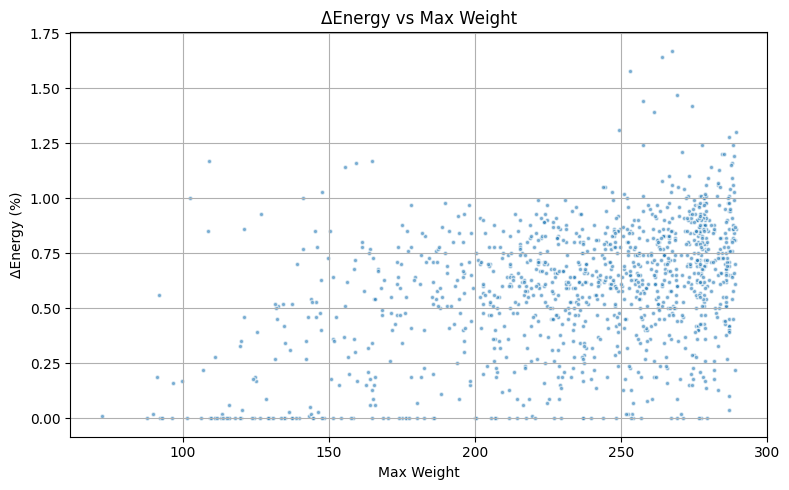

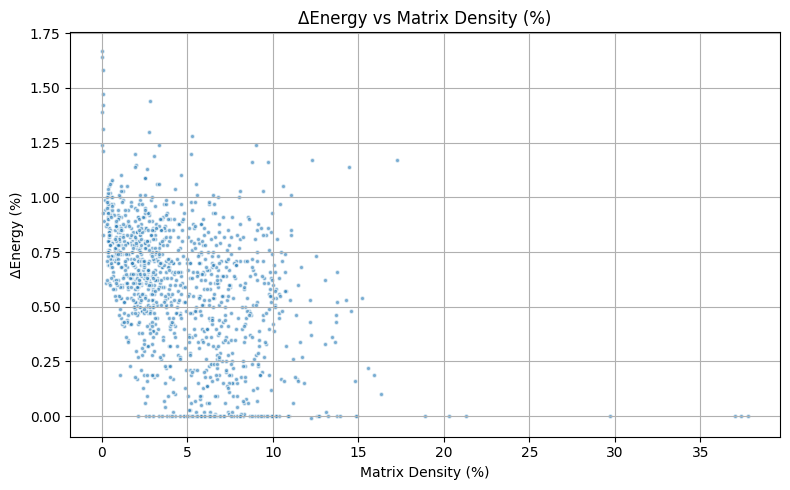

In [50]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # Assumes engine is imported from here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "qubo_energy_data.sql"

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())


# Point to src/sql/qubo_energy_data.sql
sql_file = os.path.join(base_dir, 'sql', sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean and preprocess ===
df["delta_energy"] = df["delta_energy"].str.replace('%', '', regex=False).astype(float)
df["matrix_density"] = df["matrix_density"].astype(str).str.replace('%', '', regex=False).astype(float)

# === Scatter plot helper ===
def plot_scatter(x, y="delta_energy", xlabel=None):
    plt.figure(figsize=(8, 5))
    plt.scatter(df[x], df[y], alpha=0.6, edgecolors='w', s=10)
    plt.xlabel(xlabel or x)
    plt.ylabel("ΔEnergy (%)")
    plt.title(f"ΔEnergy vs {xlabel or x}")
    plt.grid(True)
    plt.tight_layout()
    #plt.savefig(f"scatter_{x}.png")
    plt.show()

# === Generate scatter plots ===
plot_scatter("rounded_vehicles", xlabel="Number of Vehicles")
plot_scatter("lambda_value", xlabel="Lambda Value")
plot_scatter("max_weight", xlabel="Max Weight")
plot_scatter("matrix_density", xlabel="Matrix Density (%)")


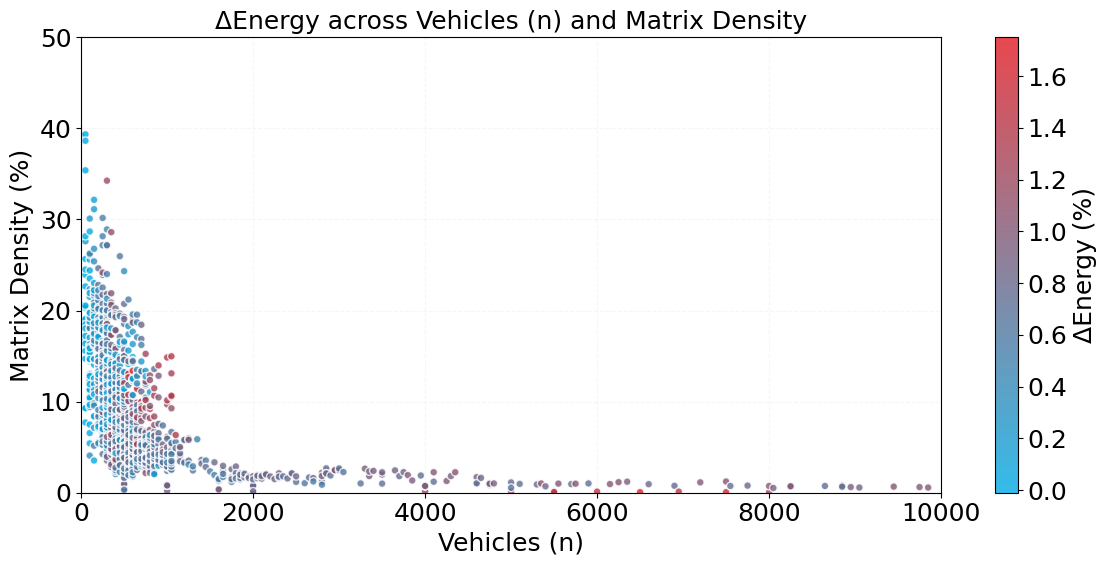

In [55]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # Assumes engine is imported from here
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === Define custom colormap from logo colors (blue → red) ===
logo_colors = ["#00ABE5", "#E21A22"]  # Blue to Red
custom_cmap = mcolors.LinearSegmentedColormap.from_list("logo_cmap", logo_colors)

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "qubo_energy_data.sql"

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())

# Point to src/sql/qubo_energy_data.sql
sql_file = os.path.join(base_dir, 'sql', sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean and preprocess ===
df["delta_energy"] = df["delta_energy"].str.replace('%', '', regex=False).astype(float)
df["matrix_density"] = df["matrix_density"].astype(str).str.replace('%', '', regex=False).astype(float)

# === Scatter plot: Vehicles vs Density, colored by ΔEnergy ===
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df["rounded_vehicles"],
    df["matrix_density"],
    c=df["delta_energy"],         # color by ΔEnergy
    cmap=custom_cmap,              # blue=low, red=high (adjustable)
    alpha=0.8,
    edgecolors="w",
    s=30
)

plt.xlabel("Vehicles (n)")
plt.ylabel("Matrix Density (%)")
plt.title("ΔEnergy across Vehicles (n) and Matrix Density")
cbar = plt.colorbar(scatter)
cbar.set_label("ΔEnergy (%)")
plt.gca().set_xlim(left=0, right=10000)
plt.gca().set_ylim(bottom=0, top=50)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})


plt.grid(True, linestyle="--", alpha=0.1)
plt.tight_layout()
plt.show()


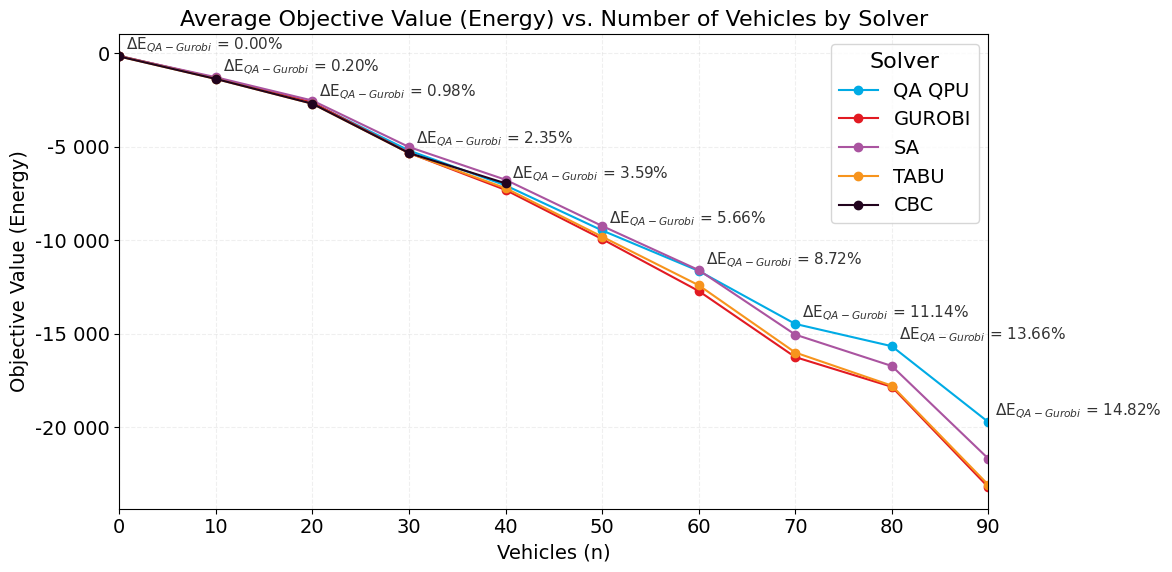

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "energy_compare_qpu.sql"  # name of your SQL file

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean & rename columns ===
# Normalize "count(*)" if DB returns it
rename_map = {}
for col in df.columns:
    if col.strip().lower() in {"count(*)", "count"}:
        rename_map[col] = "n_instances"
if rename_map:
    df = df.rename(columns=rename_map)

# Ensure expected columns exist
expected = [
    "n_vehicles",
    "qa qpu_energy",
    "gurobi_energy",
    "sa_energy",
    "tabu_energy",
    "cbc_energy",
    "delta_energy"
]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in query result: {missing}")

# Sort for consistent plotting
df = df.sort_values("n_vehicles")

# === Plot energies vs n_vehicles ===
plt.figure(figsize=(12, 6))

# Custom color palette
colors = {
    "qa qpu_energy": "#00ABE5",
    "gurobi_energy": "#E21A22",
    "sa_energy": "#AA54A0",
    "tabu_energy": "#F7941D",
    "cbc_energy": "#22041E",
}

# Plot all solver lines
for col in ["qa qpu_energy", "gurobi_energy", "sa_energy", "tabu_energy", "cbc_energy"]:
    plt.plot(
        df["n_vehicles"],
        df[col],
        marker="o",
        color=colors[col],
        label=col.replace("_energy", "").upper()
    )
    
if df["delta_energy"].dtype == object:
    df["delta_energy"] = (
        df["delta_energy"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
    )
# Add ΔEnergy annotations for QA QPU line
for _, row in df.iterrows():
    plt.annotate(
    f"ΔE$_{{QA-Gurobi}}$ = {row['delta_energy']:.2f}%",
    (row["n_vehicles"], row["qa qpu_energy"]),
    textcoords="offset points",
    xytext=(5, 5),
    ha="left",
    fontsize=11,
    color="#333333"
)


# Labels and title
plt.xlabel("Vehicles (n)")
plt.ylabel("Objective Value (Energy)")
plt.title("Average Objective Value (Energy) vs. Number of Vehicles by Solver")

# Grid and axis formatting
plt.grid(True, linestyle="--", alpha=0.2)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.gca().set_xlim(left=0, right=90)

# Font sizes
plt.rcParams.update({
    "font.size": 16,        # base font size
    "axes.titlesize": 16,   # title
    "axes.labelsize": 14,   # x/y labels
    "xtick.labelsize": 14,  # x-ticks
    "ytick.labelsize": 14,  # y-ticks
    "legend.fontsize": 14   # legend if used
})

# Legend
plt.legend(title="Solver", loc="upper right")

plt.tight_layout()
plt.show()


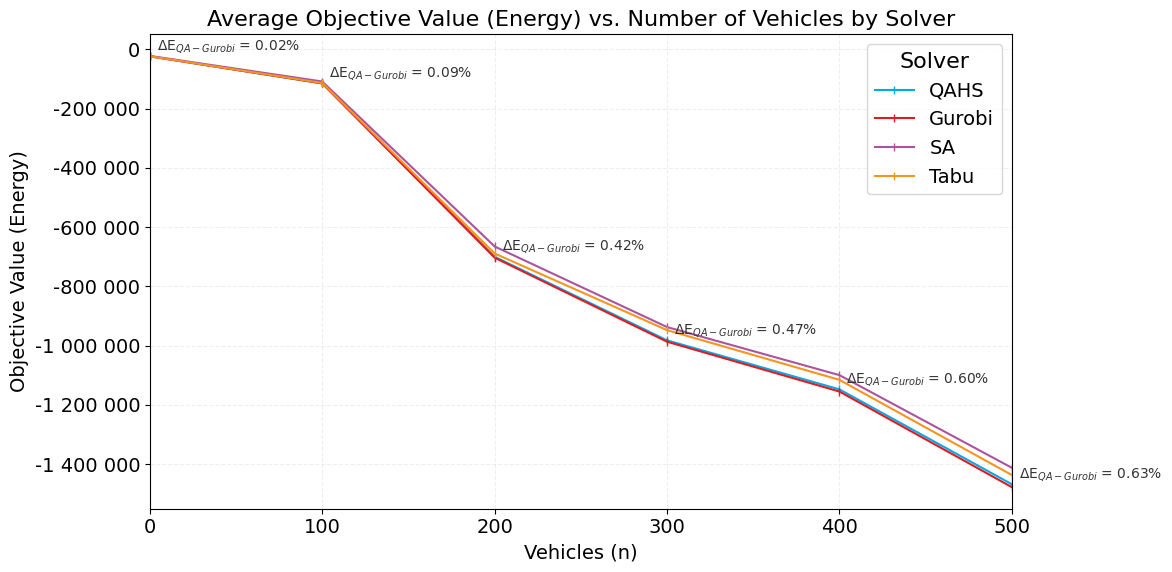

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "energy_compare_middle.sql"  # name of your SQL file

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean & rename columns ===
rename_map = {}
for col in df.columns:
    if col.strip().lower() in {"count(*)", "count"}:
        rename_map[col] = "n_instances"
if rename_map:
    df = df.rename(columns=rename_map)

# Ensure expected columns exist
expected = [
    "n_vehicles",
    "qa hybrid_energy",
    "gurobi_energy",
    "sa_energy",
    "tabu_energy",
    "delta_energy"
]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in query result: {missing}")

# Convert delta_energy to numeric if it’s stored as string with %
if df["delta_energy"].dtype == object:
    df["delta_energy"] = (
        df["delta_energy"].astype(str).str.replace("%", "", regex=False).astype(float)
    )

# Sort for consistent plotting
df = df.sort_values("n_vehicles")

# === Plot energies vs n_vehicles ===
plt.figure(figsize=(12, 6))

legend_labels = {
    "qa hybrid_energy": "QAHS",
    "gurobi_energy": "Gurobi",
    "sa_energy": "SA",
    "tabu_energy": "Tabu",
}

colors = {
    "qa hybrid_energy": "#00ABE5",
    "gurobi_energy": "#E21A22",
    "sa_energy": "#AA54A0",
    "tabu_energy":  "#F7941D",
}

# Plot solver lines
for col in ["qa hybrid_energy", "gurobi_energy", "sa_energy", "tabu_energy"]:
    plt.plot(
        df["n_vehicles"],
        df[col],
        marker="|",
        color=colors[col],
        label=legend_labels[col]
    )

# === Add ΔE annotations for QAHS vs Gurobi ===
for _, row in df.iterrows():
    plt.annotate(
        f"ΔE$_{{QA-Gurobi}}$ = {row['delta_energy']:.2f}%",
        (row["n_vehicles"], row["qa hybrid_energy"]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left",
        fontsize=10,
        color="#333333"
    )

# Labels and formatting
plt.xlabel("Vehicles (n)")
plt.ylabel("Objective Value (Energy)")
plt.title("Average Objective Value (Energy) vs. Number of Vehicles by Solver")
plt.grid(True, linestyle="--", alpha=0.2)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(100))
plt.gca().set_xlim(left=0, right=500)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14
})

plt.legend(title="Solver", loc="upper right")

plt.tight_layout()
plt.show()


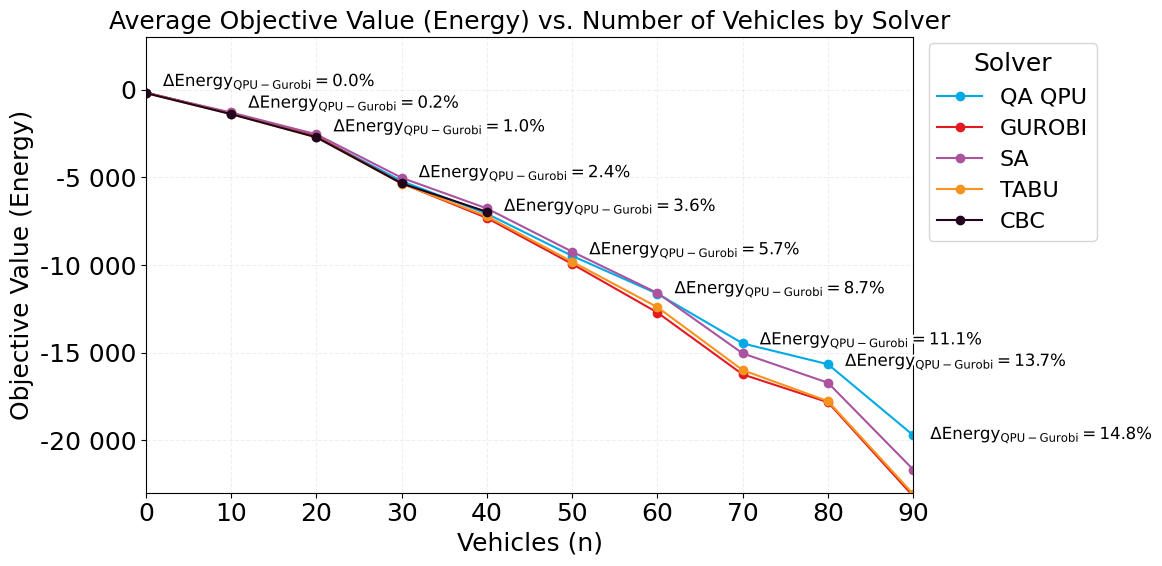

In [48]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "energy_compare_qpu.sql"  # name of your SQL file

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean & rename columns ===
rename_map = {}
for col in df.columns:
    if col.strip().lower() in {"count(*)", "count"}:
        rename_map[col] = "n_instances"
if rename_map:
    df = df.rename(columns=rename_map)

expected = [
    "n_vehicles",
    "qa qpu_energy",
    "gurobi_energy",
    "sa_energy",
    "tabu_energy",
    "cbc_energy",
    "delta_energy",  # needed for annotation
]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in query result: {missing}")

# Clean delta_energy if % present
if df["delta_energy"].dtype == object:
    df["delta_energy"] = df["delta_energy"].str.replace("%", "", regex=False).astype(float)

df = df.sort_values("n_vehicles")

# === Plot energies vs n_vehicles ===
plt.figure(figsize=(12, 6))

colors = {
    "qa qpu_energy": "#00ABE5",   # Blue
    "gurobi_energy": "#E21A22",   # Red
    "sa_energy": "#AA54A0",       # Purple
    "tabu_energy": "#F7941D",     # Orange
    "cbc_energy": "#22041E",      # Dark violet/brown
}

for col in ["qa qpu_energy", "gurobi_energy", "sa_energy", "tabu_energy", "cbc_energy"]:
    plt.plot(
        df["n_vehicles"],
        df[col],
        color=colors[col],
        marker="o",
        label=col.replace("_energy", "").upper()
    )

# === Add ΔEnergy annotations (on QA QPU curve) ===
for x, y, de in zip(df["n_vehicles"], df["qa qpu_energy"], df["delta_energy"]):
    plt.text(
        x + 2, y * 1.03,  # offset to the right & slightly above
        fr"$\Delta \mathrm{{Energy}}_{{\mathrm{{QPU - Gurobi}}}} = {de:.1f}\%$",
        fontsize=12,
        ha="left", va="bottom",
        color="black",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]  # outline for visibility
    )

plt.xlabel("Vehicles (n)")
plt.ylabel("Objective Value (Energy)")
plt.title("Average Objective Value (Energy) vs. Number of Vehicles by Solver")
plt.grid(True, linestyle="--", alpha=0.2)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.gca().set_xlim(left=0, right=90)
plt.gca().set_ylim(bottom=-23000, top=3000)

plt.legend(title="Solver", loc="center left", bbox_to_anchor=(1.02, 0.77), borderaxespad=0)
plt.tight_layout()
plt.show()


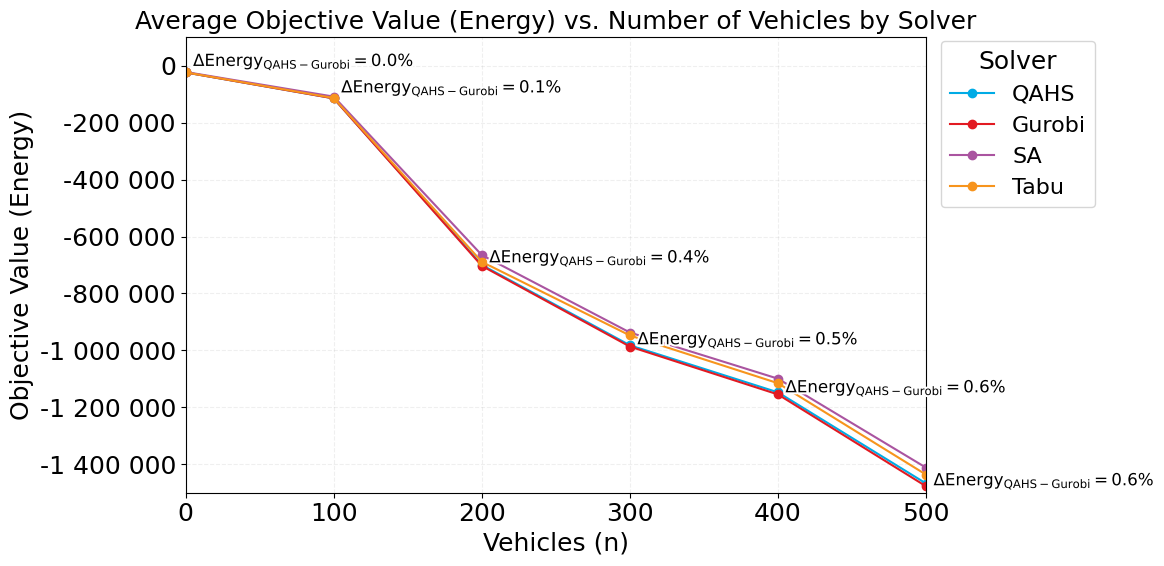

In [54]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here
import matplotlib.patheffects as pe

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "energy_compare_middle.sql"  # name of your SQL file

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# === Clean & rename columns ===
rename_map = {}
for col in df.columns:
    if col.strip().lower() in {"count(*)", "count"}:
        rename_map[col] = "n_instances"
if rename_map:
    df = df.rename(columns=rename_map)

expected = [
    "n_vehicles",
    "qa hybrid_energy",
    "gurobi_energy",
    "sa_energy",
    "tabu_energy",
    "delta_energy",  # ensure this column exists
]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in query result: {missing}")

# If delta_energy has % sign, clean it
if df["delta_energy"].dtype == object:
    df["delta_energy"] = df["delta_energy"].str.replace("%", "", regex=False).astype(float)

# Sort
df = df.sort_values("n_vehicles")

# === Plot energies vs n_vehicles ===
plt.figure(figsize=(12, 6))

colors = {
    "qa hybrid_energy": "#00ABE5",  # Blue
    "gurobi_energy": "#E21A22",     # Red
    "sa_energy": "#AA54A0",         # Purple
    "tabu_energy":  "#F7941D",      # Orange
}

legend_labels = {
    "qa hybrid_energy": "QAHS",
    "gurobi_energy": "Gurobi",
    "sa_energy": "SA",
    "tabu_energy": "Tabu"
}

for col in ["qa hybrid_energy", "gurobi_energy", "sa_energy", "tabu_energy"]:
    plt.plot(
        df["n_vehicles"],
        df[col],
        marker="o",
        color=colors[col],
        label=legend_labels[col],  # <-- use custom mapping
        linestyle="-"
    )

# === Add delta_energy as formatted text near QAHS markers ===
for x, y, de in zip(df["n_vehicles"], df["qa hybrid_energy"], df["delta_energy"]):
    plt.text(
        x + 5, y + (0.02 * y),  # offset text right & slightly above marker
        fr"$\Delta \mathrm{{Energy}}_{{\mathrm{{QAHS - Gurobi}}}} = {de:.1f}\%$",
        fontsize=12,
        ha="left", va="bottom",
        color="black",
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]  # outline for visibility
    )

plt.xlabel("Vehicles (n)")
plt.ylabel("Objective Value (Energy)")
plt.title("Average Objective Value (Energy) vs. Number of Vehicles by Solver")
plt.grid(True, linestyle="--", alpha=0.2)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(100))
plt.gca().set_xlim(left=0, right=500)
plt.gca().set_ylim(bottom=-1500000, top=100000)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

plt.legend(title="Solver", loc="center left", bbox_to_anchor=(1.02, 0.81), borderaxespad=0)
plt.tight_layout()
plt.show()


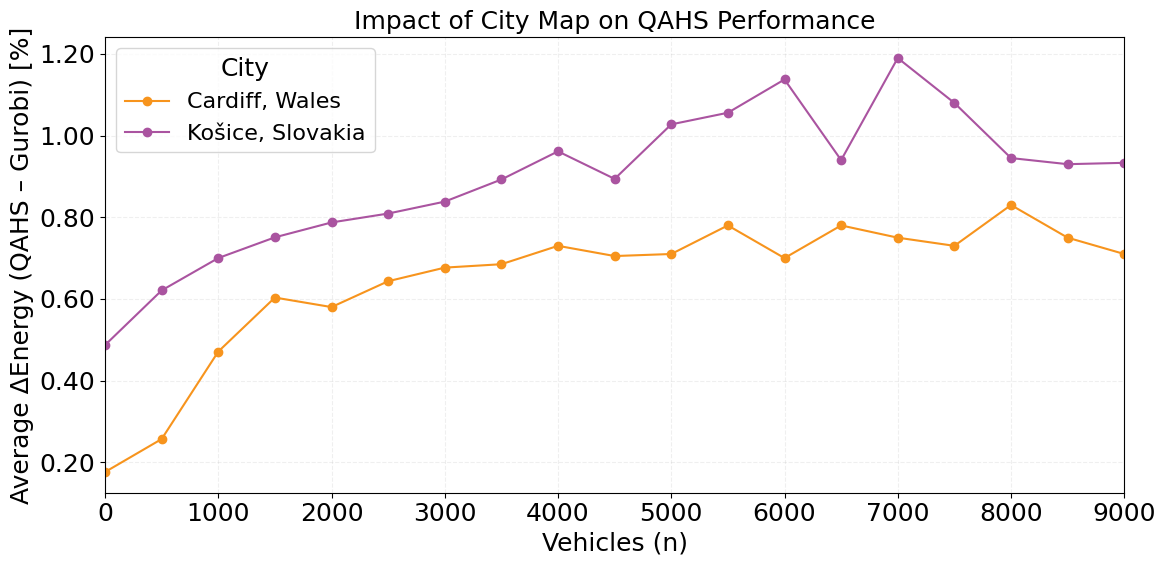

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "city_comparision.sql"

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# Sort for consistent plotting
df = df.sort_values(["veh", "name"])

# === Define custom city colors ===
city_colors = {
    "Košice, Slovakia": "#AA54A0",   # purple
    "Cardiff, Wales": "#F7941D",  # orange
}

# === Plot delta energy vs n_vehicles grouped by city ===
plt.figure(figsize=(12, 6))

for city in df["name"].unique():
    city_df = df[df["name"] == city]
    plt.plot(
        city_df["veh"],
        city_df["avg_delta_energy"],
        marker="o",
        label=city,
        color=city_colors.get(city, "gray")  # default gray if city not in dict
    )

plt.xlabel("Vehicles (n)")
plt.ylabel("Average ΔEnergy (QAHS – Gurobi) [%]")
plt.title("Impact of City Map on QAHS Performance")
plt.grid(True, linestyle="--", alpha=0.2)

# Format y-axis
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))
plt.gca().set_xlim(left=0, right=9000)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

plt.legend(title="City")
plt.tight_layout()
plt.show()


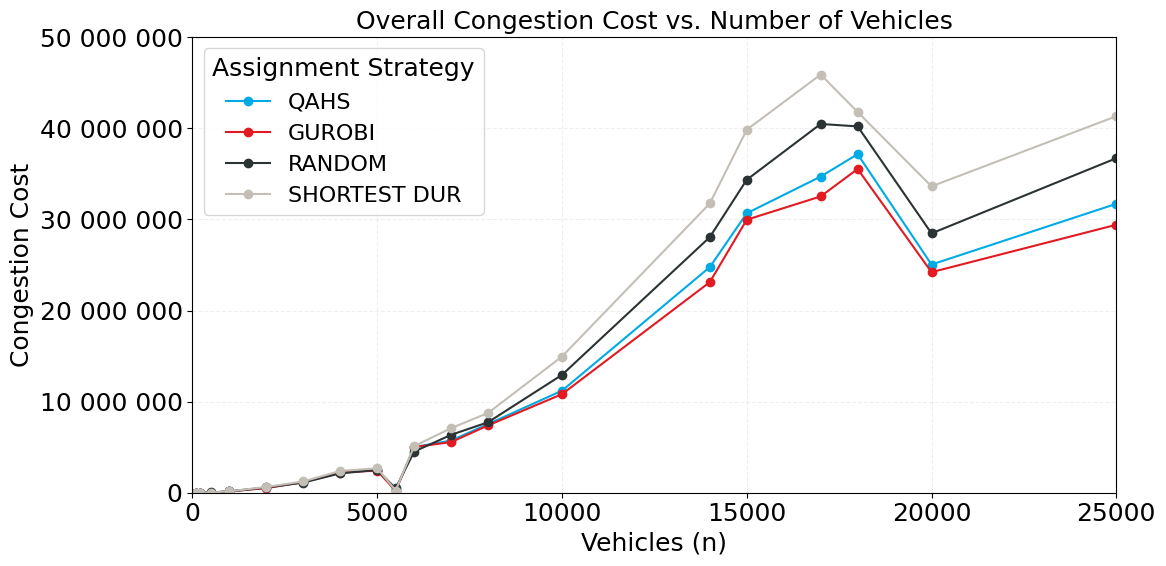

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # expects `engine` to be defined here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
sql_name = "overall_congestion.sql"

# Get base directory (e.g., .../project_root/src)
base_dir = os.path.dirname(os.getcwd())
sql_file = os.path.join(base_dir, "sql", sql_name)

# === Load SQL from file and execute ===
with open(sql_file, "r") as f:
    sql_query = f.read()

df = pd.read_sql(text(sql_query), session.bind)

# Ensure expected columns exist
expected = ["n_vehicles", "QA_HS_COST", "GUROBI_COST", "RANDOM_COST", "SHORTEST_DUR_COST"]
missing = [c for c in expected if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in query result: {missing}")

# Compute ΔCost = (QA_HS - Gurobi)/Gurobi * 100
df["delta_cost"] = ((df["QA_HS_COST"] - df["GUROBI_COST"]) / df["GUROBI_COST"]) * 100

# Sort for consistent plotting
df = df.sort_values("n_vehicles")

# === Plot congestion cost vs n_vehicles ===
plt.figure(figsize=(12, 6))

colors = {
    "QA_HS_COST": "#00ABE5",       # blue
    "GUROBI_COST": "#E21A22",      # predurple
    "RANDOM_COST": "#2B3335",      # teal
    "SHORTEST_DUR_COST": "#C4BFB6" # gold
}

# Mapping for pretty legend labels
legend_names = {
    "QA_HS_COST": "QAHS",
    "GUROBI_COST": "GUROBI",
    "RANDOM_COST": "RANDOM",
    "SHORTEST_DUR_COST": "SHORTEST DUR"
}

for col in ["QA_HS_COST", "GUROBI_COST", "RANDOM_COST", "SHORTEST_DUR_COST"]:
    plt.plot(
        df["n_vehicles"],
        df[col],
        color=colors[col],
        marker="o",
        label=legend_names[col]
    )



plt.xlabel("Vehicles (n)")
plt.ylabel("Congestion Cost")
plt.title("Overall Congestion Cost vs. Number of Vehicles")
plt.grid(True, linestyle="--", alpha=0.2)

# Format y-axis ticks with spaces as thousands separator
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().set_xlim(left=0, right=25000)
plt.gca().set_ylim(bottom=0, top=50000000)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

plt.legend(title="Assignment Strategy", loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker
from models import *  # assumes engine is imported here

def create_db_session():
    """Create a new database session."""
    Session = sessionmaker(bind=engine, autocommit=False)
    return Session()

# === Configuration ===
session = create_db_session()
base_dir = os.path.dirname(os.getcwd())

# Helper to run SQL and return df
def load_sql_result(sql_name):
    sql_file = os.path.join(base_dir, 'sql', sql_name)
    with open(sql_file, "r") as f:
        sql_query = f.read()
    df = pd.read_sql(text(sql_query), session.bind)
    df = df.rename(columns={
        "countvehicle": "degree",
        "count(distinct vehicle1)": "vehicles"
    })
    return df

# === Load both scenarios ===
df_random = load_sql_result("diversity_random.sql")
df_attraction = load_sql_result("diversity_attraction.sql")

# === Plot comparison ===
plt.figure(figsize=(12, 6))

colors = {
    "random": "#00ABE5",     # blue
    "attraction": "#F7941D"  # orange
}

plt.scatter(
    df_random["degree"], df_random["vehicles"],
    alpha=0.7, edgecolors="white", s=30,
    label="Random destinations",
    color=colors["random"]
)

plt.scatter(
    df_attraction["degree"], df_attraction["vehicles"],
    alpha=0.7, edgecolors="white", s=30,
    label="Attraction points (4 dests.)",
    color=colors["attraction"]
)

plt.xlabel("Vehicle Overlap Degree")
plt.ylabel("Vehicle Frequency")
plt.title("Comparison of Degree Distributions")

# Consistent grid style with other plots
plt.grid(True, linestyle="--", alpha=0.2)

# Format y-axis ticks with thousands separator (space instead of comma)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().set_xlim(left=0, right=1200)
plt.gca().set_ylim(bottom=0, top=100)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

plt.legend(title="Scenario", loc="upper right")
plt.tight_layout()
# plt.savefig("degree_distribution_comparison.png", dpi=300)
plt.show()
